# Alissa Beaderstadt Notebook - Exploratory Data Analysis of Restaurant Tipping Data

REQ: Open notebooks with a standard header including a good title, your company/name/alias, a link to the repo, purpose, and date.

REQ: For EDA projects, include dataset, description, and source information.

- Author: [Alissa Beaderstadt](https://github.com/abeaderstadt/)
- Repository: [datafun-04-notebooks](https://github.com/abeaderstadt/datafun-04-notebooks/)
- Purpose: Demonstrate a repeatable EDA workflow for a new, unexplored dataset
- Date: 2026-05

## Dataset Information

- Dataset: Tips
- Description: Restaurant tipping data that includes total bill amount, tip amount, customer sex, smoker status, day of the week, time of day, and party size.
- Source: Seaborn built-in dataset
- Original Collection: Data from a restaurant server's tip records, commonly used for statistical analysis and data visualization examples.
- Citation: Seaborn Tips Dataset
- Access: Available via Seaborn's built-in datasets using `sns.load_dataset("tips")`


## Section 1. Project Setup and Imports

All imports and configuration appear once, at the top of the notebook.

WHY:
- Keeps notebooks readable and reproducible
- Mirrors professional scripts
- Makes it clear what must be installed



In [68]:
# This is a Python cell.

# Imports at the top of the file
# REQ.EXTERNAL.DEPS: External packages must be defined in pyproject.toml
# REQ.EXTERNAL.DEPS.INSTALLED: external packages must be installed in the environment using uv sync command
# REQ.EXTERNAL.DEPS.IMPORTED: external packages used in this notebook must be imported here


from matplotlib.axes import Axes
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Type hint for Axes object (basic plot type returned by Seaborn)
# A seaborn plot is a set of axes and you can set the title, labels, etc. on the axes.

# A figure can contain multiple axes (plots)
# from matplotlib.figure import Figure

# Pandas display configuration (helps in notebooks)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

print("Imports complete.")

Imports complete.


## Section 2. Load the Data


WHY: Before analysis, load the data to confirm:

- The dataset loads successfully
- The structure matches expectations
- Column names are available and readable



In [53]:
# Python cell

# Load the tips dataset from Seaborn
# Into a pandas DataFrame (2D table)
tips_df: pd.DataFrame = sns.load_dataset("tips")

# Preview the first few rows
tips_df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## Section 3. Inspect Data Shape and Structure

WHY: First, understand the shape (basic structure) of the data:

- How many rows and columns are there?
- What types of data are present?
- Are there obvious missing values?

This step determines challenges we might have downstream (later).


In [54]:
# Section 3 Python cell

# Get shape - number of rows and columns
shape: tuple[int, int] = tips_df.shape

# Communicate the shape clearly
print(f"The tips dataset has {shape[0]} rows and {shape[1]} columns.")

The tips dataset has 244 rows and 7 columns.


In [55]:
# Section 3 Python cell

# Display column names and data types
tips_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [56]:
# Section 3 Python cell

# List the column names
print("Column names:")
print(list(tips_df.columns))

Column names:
['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']


## Section 4. Create Data Dictionary and Check Data Quality

WHY: Missing data is normal. We need to find out how much and where.

Missing data affects:

- Visualizations
- Summary statistics
- Machine learning models

LOOK FOR: 

- Columns with many missing values
- Patterns (entire rows missing multiple fields)



In [57]:
# Section 4 Python cell

# Count missing values in each column
print("Missing values per column:")
print(tips_df.isnull().sum())

Missing values per column:
total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64


In [58]:
# Section 4 Python cell

# Check for duplicate rows
num_duplicates = tips_df.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

Number of duplicate rows: 1


## Section 4b. Clean Data

## Section 5. Create Clean View for EDA

WHY: We often want to work with complete data for visualizations and statistics.

Strategy:
- Keep the original DataFrame unchanged
- Create a separate clean view by dropping rows with missing values


In [59]:
# Section 5 Python cell

# Create a clean view by dropping rows with any missing values
tips_clean: pd.DataFrame = tips_df.dropna()

# Compare sizes
print(f"Original dataset: {len(tips_df)} rows")
print(f"Clean dataset: {len(tips_clean)} rows")
print(f"Rows removed: {len(tips_df) - len(tips_clean)}")

Original dataset: 244 rows
Clean dataset: 244 rows
Rows removed: 0


## Section 5b. Creating Derived Features

In [60]:
# Derived feature: spending category
def add_spending_category(df: pd.DataFrame) -> pd.DataFrame:
    """Add spending categories based on total bill amount."""

    df = df.copy()

    df["spending_category"] = pd.cut(
        df["total_bill"],
        bins=[0, 15, 30, 60],
        labels=["Low", "Medium", "High"],
    )

    return df

In [61]:
# Derived feature: bill_vs_day_avg
def add_bill_vs_day_avg(df: pd.DataFrame) -> pd.DataFrame:
    """Compare each bill to the average bill for that day."""

    df = df.copy()

    day_avg = df.groupby("day")["total_bill"].transform("mean")

    df["bill_vs_day_avg"] = df["total_bill"] / day_avg

    return df

In [62]:
# Apply new feartures to the clean dataset
tips_clean = add_spending_category(tips_clean)
tips_clean = add_bill_vs_day_avg(tips_clean)

tips_clean.groupby("day").sample(3, random_state=42)

,total_bill,tip,sex,smoker,day,time,size,spending_category,bill_vs_day_avg
195,7.56,1.44,Male,No,Thur,Lunch,2,Low,0.427536
201,12.74,2.01,Female,Yes,Thur,Lunch,2,Low,0.720476
77,27.20,4.00,Male,No,Thur,Lunch,4,Medium,1.538223
223,15.98,3.00,Female,No,Fri,Lunch,3,Medium,0.931693
96,27.28,4.00,Male,Yes,Fri,Dinner,2,Medium,1.590524
220,12.16,2.20,Male,Yes,Fri,Lunch,2,Low,0.708973
237,32.83,1.17,Male,Yes,Sat,Dinner,2,High,1.606056
219,30.14,3.09,Female,Yes,Sat,Dinner,4,High,1.474460
65,20.08,3.15,Male,No,Sat,Dinner,3,Medium,0.982321
12,15.42,1.57,Male,No,Sun,Dinner,2,Medium,0.720224


## Section 6. Descriptive Statistics for Numeric Columns

WHY: Summary statistics give us a quick overview of the numeric data:

- Central tendency (mean)
- Spread (std, min, max)
- Distribution shape (quartiles)

This is a Markdown cell.

In [63]:
# Section 6 Python cell

# Summary statistics for numeric columns
tips_clean.describe()

,total_bill,tip,size,bill_vs_day_avg
count,244.000000,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672,1.000000
std,8.902412,1.383638,0.951100,0.442646
min,3.070000,1.000000,1.000000,0.150186
25%,13.347500,2.000000,2.000000,0.698371
50%,17.795000,2.900000,2.000000,0.902858
75%,24.127500,3.562500,3.000000,1.194538
max,50.810000,10.000000,6.000000,2.485644


In [64]:
# Section 6 Python cell

# Calculate statistics for total bill with numpy
mean_total_bill = np.mean(tips_clean["total_bill"])
std_total_bill = np.std(tips_clean["total_bill"])
min_total_bill = np.min(tips_clean["total_bill"])
max_total_bill = np.max(tips_clean["total_bill"])
range_total_bill = np.ptp(tips_clean["total_bill"])  # peak to peak (max - min)

print("Total Bill Statistics (using numpy):")
print(f"  Mean: ${mean_total_bill:.2f}")
print(f"  Std Dev: ${std_total_bill:.2f}")
print(f"  Min: ${min_total_bill:.2f}")
print(f"  Max: ${max_total_bill:.2f}")
print(f"  Range: ${range_total_bill:.2f}")

Total Bill Statistics (using numpy):
  Mean: $19.79
  Std Dev: $8.88
  Min: $3.07
  Max: $50.81
  Range: $47.74


## Section 7. Correlation Matrix for Numeric Columns

WHY: Correlation tells us how numeric variables relate to each other.

- Values near 1 or -1 indicate strong relationships
- Values near 0 indicate weak or no linear relationship


In [65]:
# Section 7 Python cell

# Select only numeric columns and compute correlation
numeric_cols = tips_clean.select_dtypes(include="number")
correlation_matrix = numeric_cols.corr()
print(correlation_matrix)

                 total_bill       tip      size  bill_vs_day_avg
total_bill         1.000000  0.675734  0.598315         0.979853
tip                0.675734  1.000000  0.489299         0.666625
size               0.598315  0.489299  1.000000         0.579468
bill_vs_day_avg    0.979853  0.666625  0.579468         1.000000


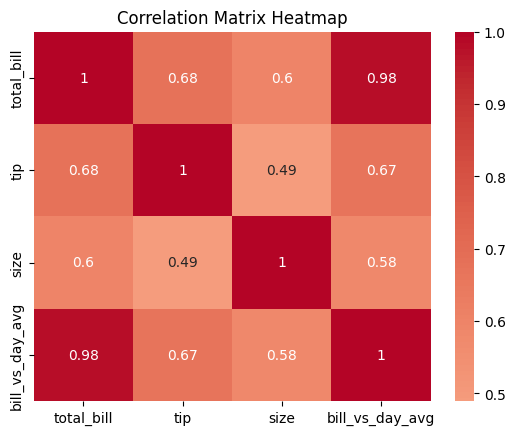

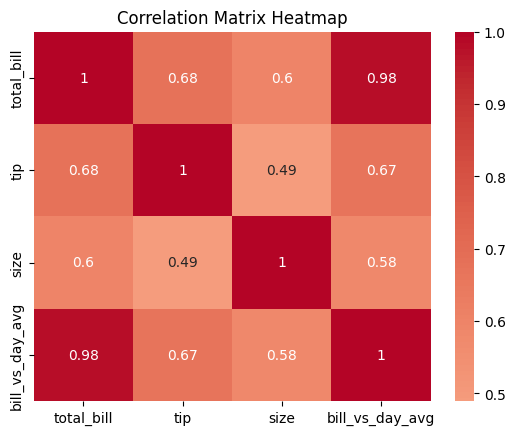

In [66]:
# Section 7 Python cell

# Visualize the correlation matrix as a heatmap
# Set annotations to True to show correlation values
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix Heatmap")
plt.show()


# Visualize the correlation matrix as a heatmap
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix Heatmap")
plt.show()

Interpretation:

 - Values close to 1 (dark red) = strong positive correlation (both increase together)
 - Values close to -1 (dark blue) = strong negative correlation (one increases, other decreases)
 - Values close to 0 (white) = little or no linear relationship
 - The diagonal is always 1 (each variable correlates perfectly with itself)

From this heatmap, we can see that total_bill and bill_vs_day_avg have a very strong positive correlation (about 0.98). This is expected since bill_vs_day_avg is derived from total_bill, meaning customers with larger bills generally have higher values in both variables.


## Section 8. Make Plots

WHY: Visualizations reveal patterns not obvious in tables.

Create:
1. A scatter plot to see relationships between two variables
2. A box plot to compare distributions across groups

This is a Markdown cell.

Text(0.5, 1.0, 'Chart 1. Total Bill vs. Tip (by Day)')

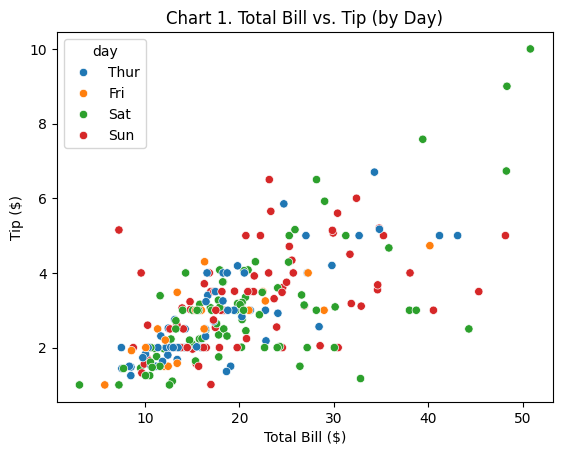

In [67]:
# Section 8 Python cell - use "Run All" so prior cells are executed first.

# Create a scatter plot of total bill vs. tip, colored by day of the week
# We need to know our dataset column names so we can use them to set x, y, and hue (color)
scatter_plt: Axes = sns.scatterplot(data=tips_clean, x="total_bill", y="tip", hue="day")

# Set axis labels using the Matplotlib Axes methods set_xlabel() and set_ylabel()
scatter_plt.set_xlabel("Total Bill ($)")
scatter_plt.set_ylabel("Tip ($)")

# Set the title using the Matplotlib Axes set_title() method
scatter_plt.set_title("Chart 1. Total Bill vs. Tip (by Day)")

# Run by clicking Run All in the Menu up top

## Section 9. Reminder: Run All before sending to GitHub

Before saving a notebook (and running git add-commit-push), click 'Run All' to generate all outputs and display them in the notebook. 

